In [116]:
import numpy as np
import matplotlib.pyplot as plt
import random
import zarr
from typing import Dict, List, Tuple, Optional
# import sys
# sys.path.insert(0, '/app')
# from src.Data.data_utils import get_training_data

In [107]:


def create_experiment_split(zarr_path: str, split_ratio: float = 0.5) -> dict[str, list]:

    store = zarr.open(zarr_path, mode="r")
    images_group = store["images"]

    data_list = []
    for name in images_group.keys():
        label = images_group[name].attrs.get("label", "unknown")
        data_list.append({"name": name, "label": label})

    random.shuffle(data_list)
    mid = int(len(data_list) * split_ratio)
    split = {"train": data_list[:mid], "test": data_list[mid:]}
    return split


def get_training_data(
    split: list | None = None,
    zarr_path: str ="/mnt/ssd3/eirik/ProcessedData/microplastics_library.zarr",
    spectra_per_class: int = 8,
    patch_size: int = 128,
    background_max: float = 0.1,
    sample_min: float = 0.5
) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict[str, int]]:

    root = zarr.open(zarr_path, mode="r")
    images_group = root["images"]
    wn = np.asarray(root.attrs["wavenumbers"], dtype=np.float32)
    if split is None:
        split = [
            {"name": name, "label": images_group[name].attrs.get("label", name)}
            for name in images_group.keys()
        ]

    unique_labels = sorted(list(set(item["label"] for item in split)))
    rng = np.random.default_rng()

    spec_per_image = max(1, spectra_per_class // len(unique_labels))
    all_spectra, all_labels = [], []
    label_encoding = {"bkg": 0}
    for i, label in enumerate(unique_labels):
        names = [item["name"] for item in split if item["label"] == label]

        p_sample, p_bkg = [], []
        while len(p_sample) < spectra_per_class or len(p_bkg) < spectra_per_class:
            name = names[rng.integers(len(names))]
            z_arr = images_group[name]["data"]
            H, W, L = z_arr.shape
            max_h = max(1, H - patch_size)
            max_w = max(1, W - patch_size)
            y0 = rng.integers(0, max_h) if H > patch_size else 0
            x0 = rng.integers(0, max_w) if W > patch_size else 0
            patch = z_arr[y0 : y0 + patch_size, x0 : x0 + patch_size]
            spectra = patch.reshape(-1, L)
            means = spectra.mean(axis=1)
            spec_mask = means > sample_min
            bkg_mask = means < background_max
        
            if spec_mask.any() and bkg_mask.any():
                if len(p_sample) < spectra_per_class:
                    valid = spectra[spec_mask]
                    k = min(spec_per_image, len(valid))
                    chosen = rng.choice(len(valid), size=k, replace=False)
                    p_sample.extend(valid[chosen])
            
                if len(p_bkg) < spectra_per_class:
                    valid = spectra[bkg_mask]
                    k = min(spec_per_image, len(valid))
                    chosen = rng.choice(len(valid), size=k, replace=False)
                    p_bkg.extend(valid[chosen])
        
        N_bkg_per_class = max(1, int(len(p_sample) / (len(unique_labels) * 2)))
        all_spectra.append(np.stack(p_sample[:spectra_per_class]))
        all_spectra.append(np.stack(p_bkg[:N_bkg_per_class]))

        all_labels.append(np.ones(spectra_per_class) * (i + 1))
        all_labels.append(np.zeros(N_bkg_per_class))
        label_encoding[label] = i + 1

    return np.hstack(all_labels), np.vstack(all_spectra), wn, label_encoding



In [ ]:
import random 
zarr_path = "/mnt/ssd3/eirik/ProcessedData/microplastics_library.zarr"
split = create_experiment_split(zarr_path, split_ratio = 0.5)

In [103]:
labels, spectra, wn, label_encoding = get_training_data(split = None,
                                                          zarr_path = zarr_path,
                                                          spectra_per_class = 4,
                                                          patch_size = 128,
                                                          background_max = 0.1,
                                                          sample_min = 0.5)

In [104]:
inverted_encoding = {value: key for key, value in label_encoding.items()}

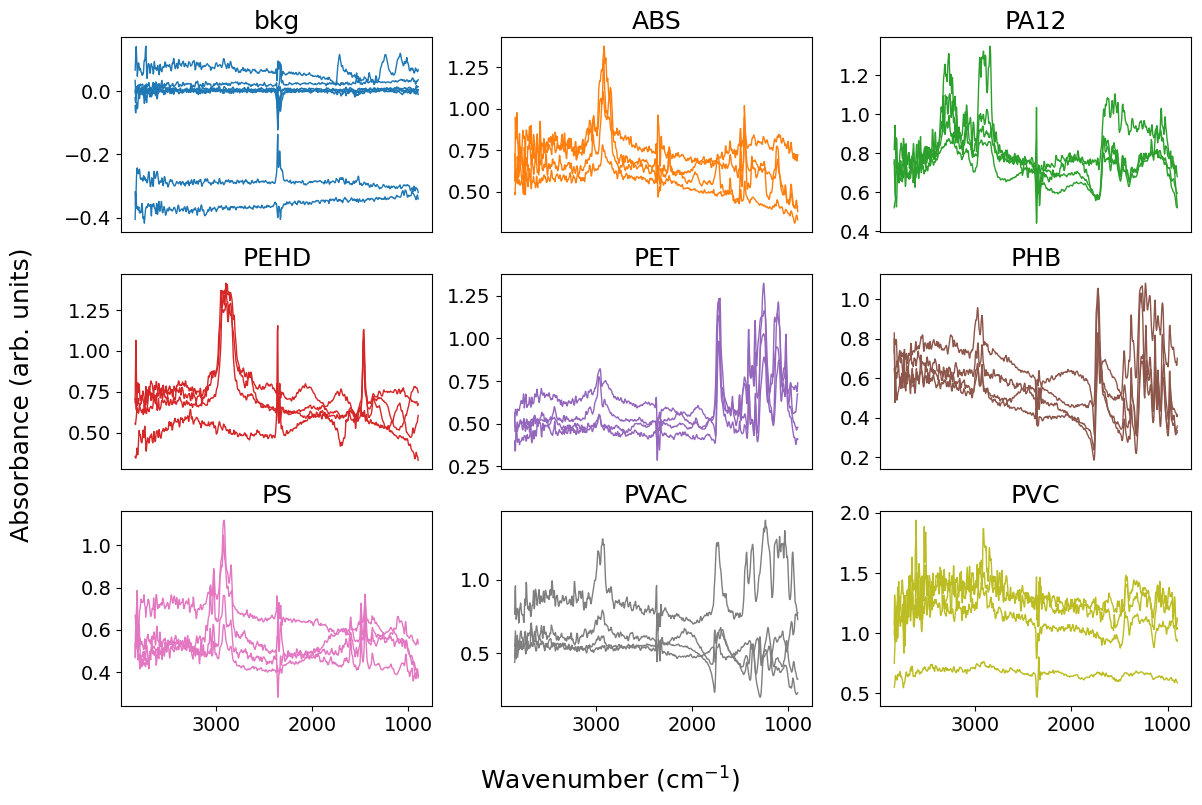

In [105]:
fig, axs = plt.subplots(nrows=3, ncols=3, sharex=True, sharey=False, figsize=(12, 8))
axs = axs.flatten()

colors = plt.cm.tab10(range(len(axs)))

for i, ax in enumerate(axs):

    ax.plot(wn, spectra[labels == i].T, color=colors[i], lw=1)

    ax.invert_xaxis()  
    ax.tick_params(axis='both', which='both', labelsize=14) 
    ax.set_title(f'{inverted_encoding[i]}', fontsize=18)  

    if i < 6:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

fig.supxlabel('Wavenumber (cm$^{-1}$)', fontsize=18, y=0.)  
fig.supylabel('Absorbance (arb. units)', fontsize=18, x=0.)  

plt.tight_layout()
# fig.suptitle('Spectra by Plastic', fontsize=20, y=1.05)
fig.savefig(
    'spectra_by_plastic.svg',
    format='svg',
    bbox_inches='tight',
    transparent=False, 
    metadata={'Date': 'Today'}  
)
plt.show()